In [172]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='darkgrid', palette='Dark2')


In [173]:
data=pd.read_csv('mobile-data.csv')
data

,Screen Size (inches),RAM (GB),Storage (GB),Battery Capacity (mAh),Camera Quality (MP),Price ($)
0,6.2,4,64,4000,48,500
1,6.1,3,128,3110,12,800
2,6.5,6,256,4500,64,600
3,6.7,8,128,4300,48,700
4,6.4,6,128,4200,40,550
...,...,...,...,...,...,...
287,6.0,6,64,3700,12,750
288,6.3,4,128,4025,32,450
289,6.6,8,256,5000,48,700
290,6.5,6,128,4500,64,550


In [174]:
data.isnull().sum()

Screen Size (inches)      0
RAM (GB)                  0
Storage (GB)              0
Battery Capacity (mAh)    0
Camera Quality (MP)       0
Price ($)                 0
dtype: int64

In [175]:
data.columns=['screen','ram','storage','battery','camera','price']

In [176]:
data

,screen,ram,storage,battery,camera,price
0,6.2,4,64,4000,48,500
1,6.1,3,128,3110,12,800
2,6.5,6,256,4500,64,600
3,6.7,8,128,4300,48,700
4,6.4,6,128,4200,40,550
...,...,...,...,...,...,...
287,6.0,6,64,3700,12,750
288,6.3,4,128,4025,32,450
289,6.6,8,256,5000,48,700
290,6.5,6,128,4500,64,550


In [177]:
for i in data.columns:
    print(f"Unique values in '{i}':")
    print(data[i].unique())
    print("-" * 40)


Unique values in 'screen':
[6.2 6.1 6.5 6.7 6.4 6.  6.3 6.6 5.8 5.7 5.9 6.8 6.9]
----------------------------------------
Unique values in 'ram':
[4 3 6 8]
----------------------------------------
Unique values in 'storage':
[ 64 128 256  32]
----------------------------------------
Unique values in 'battery':
[4000 3110 4500 4300 4200 3700 4025 5000 3000 3500 3800 4100 4400 3100
 4600 4700]
----------------------------------------
Unique values in 'camera':
[48 12 64 40 32 16 24 20]
----------------------------------------
Unique values in 'price':
[500 800 600 700 550 750 450 400 650 900]
----------------------------------------


<Axes: xlabel='screen', ylabel='price'>

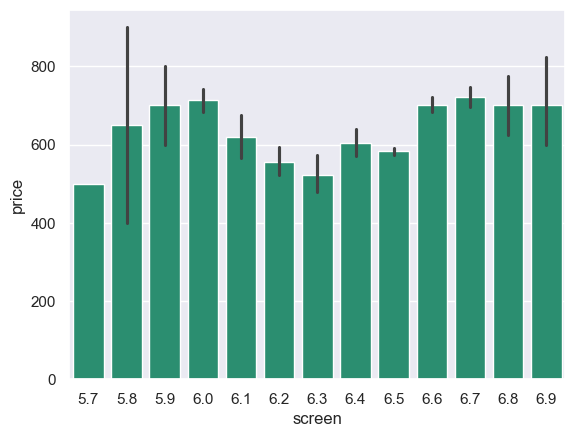

In [178]:
sns.barplot(x=data.screen , y=data.price)

<Axes: xlabel='ram', ylabel='price'>

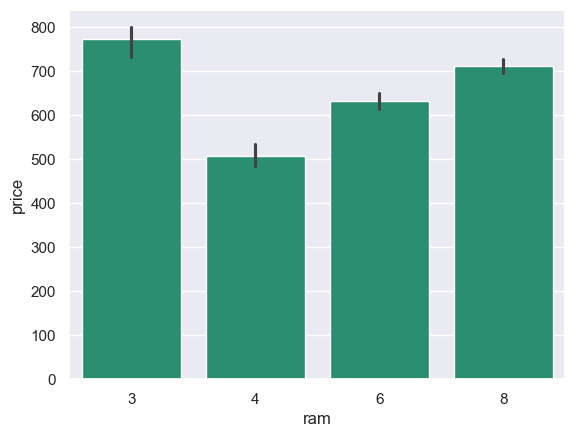

In [179]:
sns.barplot(x=data.ram , y=data.price)

<Axes: xlabel='storage', ylabel='price'>

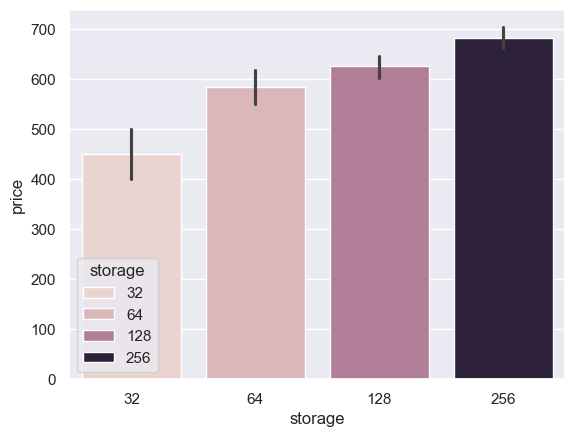

In [180]:
sns.barplot(x=data.storage , y=data.price , hue=data.storage)

<Axes: xlabel='camera', ylabel='price'>

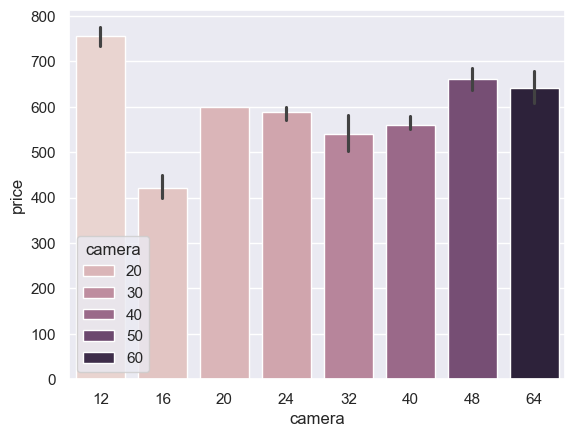

In [181]:
sns.barplot(x=data.camera , y=data.price , hue=data.camera)

C:\Users\anime\AppData\Local\Temp\ipykernel_12568\2512490203.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=data.battery )


<Axes: ylabel='Density'>

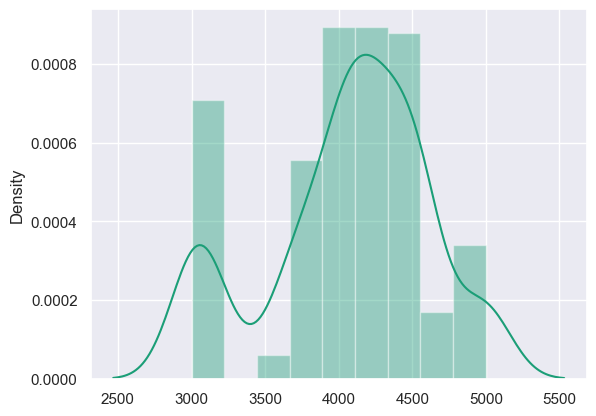

In [182]:
sns.distplot(x=data.battery )

<Axes: xlabel='battery', ylabel='price'>

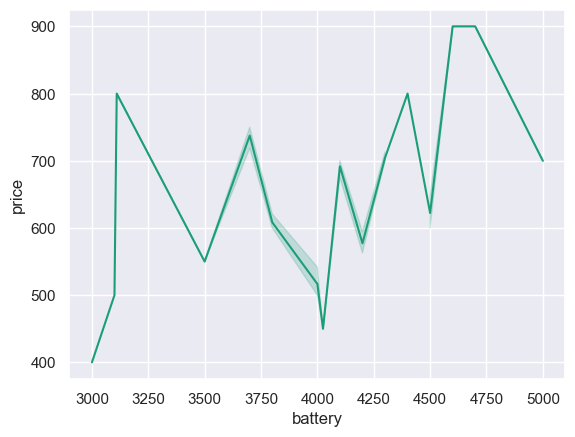

In [183]:
sns.lineplot(x=data.battery , y=data.price)

<Axes: >

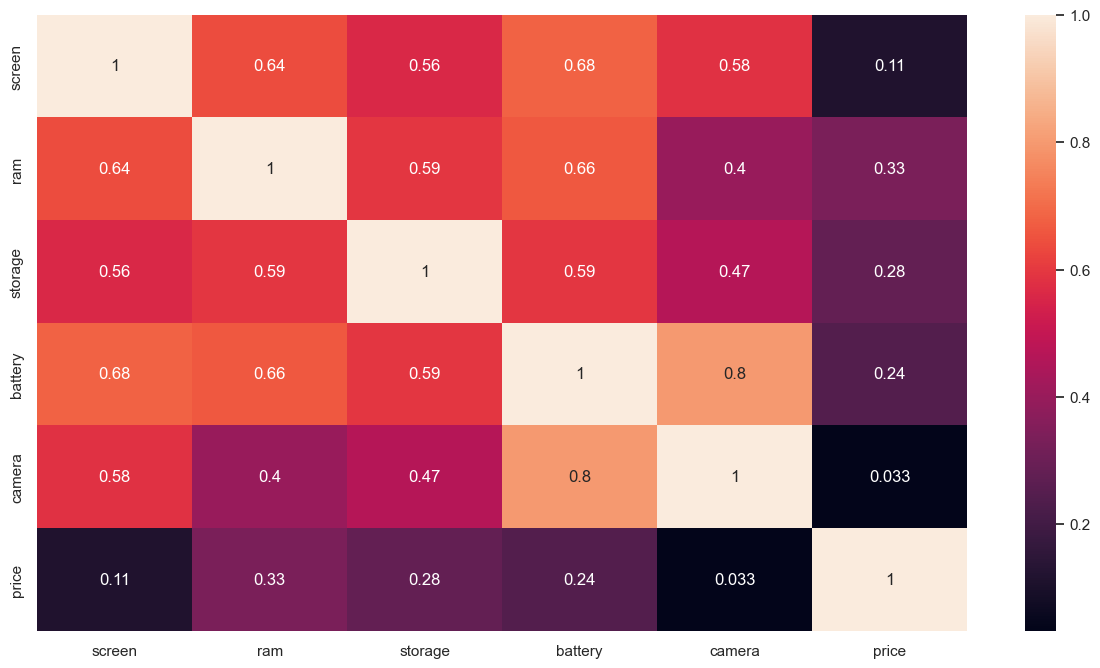

In [184]:
plt.figure(figsize=(15,8))
sns.heatmap(data=data.corr() , annot=True)

In [185]:
inputs=data.drop(['price'] , axis=1)
output=data['price']

In [186]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(inputs , output , test_size=0.23)


In [187]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test) 

In [188]:
from sklearn.linear_model import LinearRegression
alg=LinearRegression().fit(x_train,y_train)
pred=alg.predict(x_test)
print(alg.score(x_test,y_test))

0.16402265004487482


In [189]:
from sklearn.metrics import r2_score , mean_squared_error
print(mean_squared_error(y_test,pred))
print(r2_score(y_test,pred))

18068.247481512808
0.16402265004487482


# Linear reg not working so we will use another model

# polynomial Regression

In [198]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures()

x_for_poly = poly.fit_transform(x_train)

reg=LinearRegression()
reg.fit(x_for_poly , y_train)
new_x_test=poly.fit_transform(x_test)
pred_y=reg.predict(new_x_test)

print(reg.score(new_x_test,y_test))

from sklearn.metrics import mean_squared_error , r2_score
print(mean_squared_error(pred_y , y_test))
print(r2_score(pred_y , y_test))

0.5659058852677653
9382.2157928935
0.6417926815752744


In [201]:
from sklearn.linear_model import Ridge
R=Ridge(alpha=0.9)
R.fit(x_train , y_train)
yp1=R.predict(x_test)
from sklearn.metrics import mean_squared_error , r2_score
print(mean_squared_error(y_test , yp1))
print(r2_score(y_test , yp1))
# print(R.score(yp1,y_test))


18064.799769724235
0.16418216794872054


# Using Deep Learning


In [192]:
import keras

In [193]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [194]:
# model = Sequential()
# adam = Adam(learning_rate=0.01)
# model.add(Dense(30 , input_dim = 5 , activation='relu'))
# model.add(Dense(10 , activation='relu'))
# model.add(Dense(1))
# model.compile(optimizer=adam , loss='mse')

In [195]:
# model.fit(x_train , y_train, epochs=500)

In [196]:
# predictions = model.predict(x_test)

# from sklearn.metrics import r2_score , mean_squared_error
# print(f'r2_score = {r2_score(predictions , y_test)}')
# print(f'mean_squared_error = {mean_squared_error(predictions , y_test)}')